In [1]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="hpml_project_spring25",
    # Set the wandb project where this run will be logged.
    project="my-awesome-project",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

# Simulate training.
epochs = 10
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()

wandb: Currently logged in as: a-chaudhary (hpml_project_spring25) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


acc,▁▅▇▆▇█▇▇
loss,█▄▁▂▁▁▁▂
acc,0.69406
loss,0.30862


In [2]:
import torch
import torch.nn as nn
import numpy as np
import random

from kan import KAN
from kan.utils import create_dataset

import wandb
# import torch.profiler
# import fvcore
import time


import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.__version__)

cuda 2.7.0+cu128


In [3]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.version.git_version)

2.7.0+cu128
12.8
134179474539648ba7dee1317959529fbd0e7f89


In [4]:
x = torch.randn(64, 64).cuda()
w = torch.randn(64, 64).cuda()

with torch.autograd.profiler.profile(use_cuda=True) as prof:
    y = torch.matmul(x, w)

print(sum([e.flops for e in prof.key_averages() if e.flops is not None]))

C:\Users\chaud\AppData\Local\Temp\ipykernel_50328\440910674.py:4: FutureWarning: The attribute `use_cuda` will be deprecated soon, please use ``use_device = 'cuda'`` instead.
  with torch.autograd.profiler.profile(use_cuda=True) as prof:


0


In [5]:
# Define target function from KAN paper
def target_func(x):
    return torch.exp(torch.sin(torch.pi * x[:,0]) + x[:, 1]**2)

from torch.distributions.normal import Normal
eps = eps = 1e-6

f = lambda x: (
    x[:, [0]].clamp(min=eps) * Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] + 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    ) -
    x[:, [1]].clamp(min=eps) * torch.exp(-x[:, [3]] * x[:, [2]]) *
    Normal(0, 1).cdf(
        (torch.log((x[:, [0]] / x[:, [1]].clamp(min=eps)).clamp(min=eps)) +
         (x[:, [3]] - 0.5 * x[:, [4]]**2) * x[:, [2]]) /
        (x[:, [4]].clamp(min=eps) * torch.sqrt(x[:, [2]].clamp(min=eps)) + eps)
    )
)

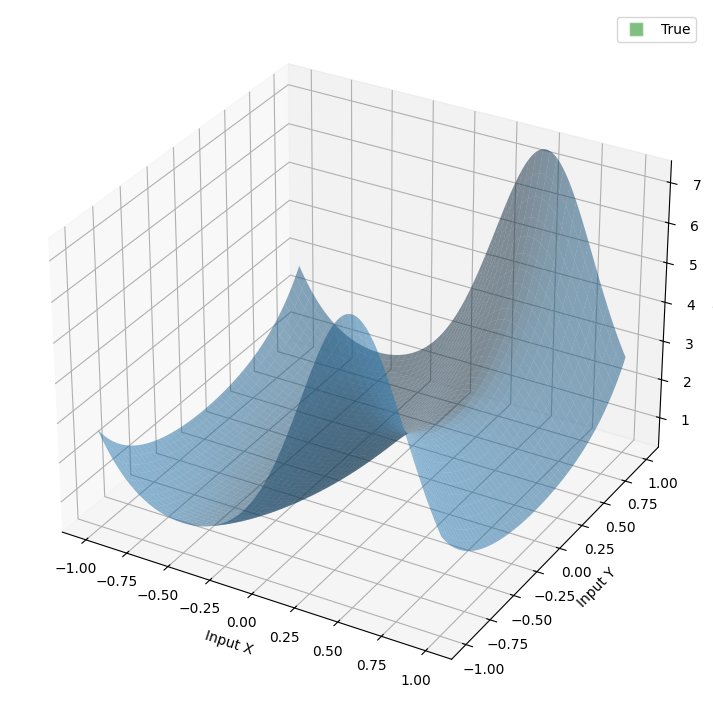

In [6]:


# Create a 2D grid of inputs
grid_size = 1000  # 100x100 grid = 10,000 points
x_vals = torch.linspace(-1, 1, grid_size)
y_vals = torch.linspace(-1, 1, grid_size)
X, Y = torch.meshgrid(x_vals, y_vals, indexing='ij')

# Flatten the grid and pass it to the target function
grid_input = torch.stack([X.flatten(), Y.flatten()], dim=1)
# print(grid_input)

# Assume target_func takes a [N, 2] input and returns a [N] or [N, 1] output
Z = target_func(grid_input).reshape(grid_size, grid_size)

# Plot the surface
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X.numpy(), Y.numpy(), Z.numpy(), label = 'True', alpha = 0.5)

from matplotlib.lines import Line2D

legend_proxy = Line2D([0], [0], marker='s', color='w', label='True',
                      markerfacecolor='green', markersize=10, alpha=0.5)

ax.set_xlabel('Input X')
ax.set_ylabel('Input Y')
ax.set_zlabel('Label Z')
ax.legend(handles= [legend_proxy])
plt.show()


In [7]:
def count_parameters(model):
    """Count trainable parameters in a PyTorch model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
def build_mlp(input_dim:int, hidden_dim:int, output_dim:int, target_kan:KAN, *, copy_mlp = None, seed=1, verbose=False):
    """Build MLP with comparable parameters"""
    # MLP params formula: (input*hidden) + hidden + (hidden*output) + output
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    mlp = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim)
    )
    kan_params = count_parameters(target_kan)
    mlp_params = count_parameters(mlp)
    if verbose:
        print(mlp_params, kan_params)
    difference = abs(kan_params - mlp_params)
    while difference != 0:
        hidden_dim += 1
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        mlp_params = count_parameters(mlp)
        if verbose:
            print(mlp_params, kan_params, hidden_dim)

        if abs(kan_params - mlp_params) > difference:
            hidden_dim -=1
            mlp = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, output_dim)
            )
            mlp_params = count_parameters(mlp)
            if verbose:
                print('final', mlp_params, kan_params, hidden_dim)
            break
        difference = abs(kan_params - mlp_params)

    
    if copy_mlp is not None:
        old_hidden_dim = copy_mlp[0].out_features

        new_fc1 = nn.Linear(input_dim, hidden_dim)
        new_fc2 = nn.Linear(hidden_dim, output_dim)

        with torch.no_grad():
            old_fc1 = copy_mlp[0]
            new_fc1.weight[:old_hidden_dim] = old_fc1.weight
            new_fc1.bias[:old_hidden_dim] = old_fc1.bias

            old_fc2 = copy_mlp[2]
            new_fc2.weight[:, :old_hidden_dim] = old_fc2.weight
            new_fc2.bias[:old_hidden_dim] = old_fc2.bias

        mlp = nn.Sequential(
            new_fc1,
            nn.ReLU(),
            new_fc2
        )

    return mlp, hidden_dim

In [9]:
# Create dataset
n_var = 5
ranges = [-1, 1]
train_num: int = 10000
test_num: int = 10000
dataset = create_dataset(f, n_var=n_var, ranges=ranges, train_num=train_num, test_num=test_num, device=device)

In [10]:
# Initialize W&B project
wandb.init(
    entity="hpml_project_spring25",
    project="KAN-MLP-Comparison",
    config={
    "seed": random.randint(0, 200),
    "grid_size": 5,
    "epochs": 100,
    "lr": 0.01,
    # "batch_size": 256,
    "equation": "exp(sin(\pi x) + x**2)",
    "n_var": n_var,
    "ranges": ranges,
    "train_num": train_num,
    "test_num": test_num,
    "input_dim": n_var,
    "kan_hidden_dim": 5,
    "mlp_hidden_dim": None,
    "output_dim": 1,
    "spline_order":3, 
})

In [11]:
# Initialize models
# from fvcore.nn import FlopCountAnalysis

kan = KAN(
    width=[wandb.config.input_dim, wandb.config.kan_hidden_dim, wandb.config.output_dim], 
    grid=wandb.config.grid_size, 
    k=wandb.config.spline_order, 
    seed=wandb.config.seed, 
    device=device)
kan_params = count_parameters(kan)

mlp, mlp_hidden_dim = build_mlp(wandb.config.input_dim, 1, wandb.config.output_dim, kan, seed=wandb.config.seed)
mlp = mlp.to(device)
wandb.config.mlp_hidden_dim = mlp_hidden_dim

mlp_params = count_parameters(mlp)

wandb.config.kan_params = kan_params
wandb.config.mlp_params = mlp_params


# Track gradients and parameters
wandb.watch((kan, mlp), log="all")

# Loss and optimizers
criterion = torch.nn.MSELoss()
kan_optim = torch.optim.Adam(kan.parameters(), lr=wandb.config.lr)
mlp_optim = torch.optim.Adam(mlp.parameters(), lr=wandb.config.lr)

grid_size = wandb.config.grid_size 

# Training loop
for epoch in range(wandb.config.epochs):
    kan.train()
    mlp.train()
    
    # KAN training
    kan_optim.zero_grad()
    torch.cuda.synchronize()
    start_time = time.perf_counter()
    kan_pred = kan(dataset['train_input'])
    kan_loss = criterion(kan_pred, dataset['train_label'])
    kan_loss.backward()
    torch.cuda.synchronize()
    duration_kan = (time.perf_counter() - start_time)
    kan_optim.step()

    # MLP training
    mlp_optim.zero_grad()
    torch.cuda.synchronize()
    start_time = time.perf_counter()
    mlp_pred = mlp(dataset['train_input'])
    mlp_loss = criterion(mlp_pred, dataset['train_label'])
    mlp_loss.backward()
    torch.cuda.synchronize()
    duration_mlp = (time.perf_counter() - start_time)
    mlp_optim.step()

    

    # Validation
    with torch.no_grad():
        kan.eval()
        mlp.eval()

        import time
        start_time = time.perf_counter()
        kan_val = criterion(kan(dataset['test_input']), dataset['test_label'])
        end_time = time.perf_counter()
        wandb.log({'kan inference_time': end_time - start_time})
        start_time = time.perf_counter()
        mlp_val = criterion(mlp(dataset['test_input']), dataset['test_label'])
        end_time = time.perf_counter()
        wandb.log({'mlp inference_time': end_time - start_time})

        # flop_kan = FlopCountAnalysis(kan, dataset['train_input']).total()
        # flop_mlp = FlopCountAnalysis(mlp, dataset['train_input']).total()

        # print('flop duration mlp', flop_mlp, duration_mlp)
        # flops_per_sec_kan = flop_kan / duration_kan
        # flops_per_sec_mlp = flop_mlp / duration_mlp

    # Log metrics
    wandb.log({
        "epoch": epoch,
        "kan_train_loss": kan_loss.item(),
        "mlp_train_loss": mlp_loss.item(),
        "kan_val_loss": kan_val.item(),
        "mlp_val_loss": mlp_val.item(),
        "kan_val_rmse": torch.sqrt(kan_val).item(),
        "mlp_val_rmse": torch.sqrt(mlp_val).item(),
        "kan_trainable_params": count_parameters(kan),
        "mlp_trainable_params": count_parameters(mlp),
        # "kan_flops": flop_kan,
        # "mlp_flops": flop_mlp,
        # "kan_flops_per_sec": flops_per_sec_kan,
        # "mlp_flops_per_sec": flops_per_sec_mlp,
        "kan_train_time_per_epoch_sec": duration_kan,
        "mlp_train_time_per_epoch_sec": duration_mlp,
    })

    if (epoch + 1) % 10 == 0:
        wandb.config.grid_size += 5
        kan = kan.refine(wandb.config.grid_size)
        kan_optim = torch.optim.Adam(kan.parameters(), lr=wandb.config.lr)

        mlp, _ = build_mlp(wandb.config.input_dim, 1, wandb.config.output_dim, kan, copy_mlp=mlp, seed=wandb.config.seed)
        mlp = mlp.to(device)
        mlp_optim = torch.optim.Adam(mlp.parameters(), lr=wandb.config.lr)

# Final evaluation
with torch.no_grad():
    kan.eval()
    mlp.eval()
    

    grid_plot_size = 100
    # Generate predictions
    x = torch.linspace(wandb.config.ranges[0], wandb.config.ranges[1], grid_plot_size)
    X1, X2, X3, X4, X5 = torch.meshgrid(x, x, x, x, x, indexing='ij')
    grid_input = torch.stack([X1.flatten(), X2.flatten()], dim=1).to(device)

    Z = f(grid_input).reshape(grid_plot_size, grid_plot_size)
    kan_pred = kan(grid_input).cpu().reshape(grid_plot_size, grid_plot_size)
    mlp_pred = mlp(grid_input).cpu().reshape(grid_plot_size, grid_plot_size)

    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_subplot(111, projection='3d')
    # Plot surfaces
    ax.plot_surface(X.cpu().numpy(), Y.cpu().numpy(), Z.cpu().numpy(), alpha=0.5, color='cyan')
    ax.plot_surface(X.cpu().numpy(), Y.cpu().numpy(), kan_pred.cpu().numpy(), alpha=0.5, color='magenta')
    ax.plot_surface(X.cpu().numpy(), Y.cpu().numpy(), mlp_pred.cpu().numpy(), alpha=0.5, color='yellow')

    # Create proxy artists for legend
    legend_proxies = [
        Line2D([0], [0], marker='s', linestyle='none', markersize=10, 
            markerfacecolor='cyan', alpha=0.5, label='True'),
        Line2D([0], [0], marker='s', linestyle='none', markersize=10, 
            markerfacecolor='magenta', alpha=0.5, label='KAN'),
        Line2D([0], [0], marker='s', linestyle='none', markersize=10, 
            markerfacecolor='yellow', alpha=0.5, label='MLP')
    ]

    ax.set_xlabel('Input X')
    ax.set_ylabel('Input Y')
    ax.set_zlabel('Label Z')
    ax.legend(handles=legend_proxies)
    wandb.log({"predictions": wandb.Image(fig)})
    plt.close()

# Parametric complexity analysis
wandb.log({
    "kan_vs_mlp_complexity": wandb.plot.line_series(
        xs=[wandb.config.epochs, wandb.config.epochs],
        ys=[[sum(p.numel() for p in kan.parameters())], 
            [sum(p.numel() for p in mlp.parameters())]],
        title="Model Complexity",
        xname="Epochs",
        keys=["KAN", "MLP"]
    )
})

wandb.finish()


checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1
saving model version 0.2
saving model version 0.3
saving model version 0.4
saving model version 0.5
saving model version 0.6
saving model version 0.7
saving model version 0.8
saving model version 0.9
saving model version 0.10


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
